<a href="https://colab.research.google.com/github/WarriorQueenX/intelligent-laptop-price-prediction/blob/main/Eda_Project_Batch_14_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving laptops.csv to laptops (1).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Laptop        2160 non-null   object 
 1   Status        2160 non-null   object 
 2   Brand         2160 non-null   object 
 3   Model         2160 non-null   object 
 4   CPU           2160 non-null   object 
 5   RAM           2160 non-null   int64  
 6   Storage       2160 non-null   int64  
 7   Storage type  2118 non-null   object 
 8   GPU           789 non-null    object 
 9   Screen        2156 non-null   float64
 10  Touch         2160 non-null   object 
 11  Final Price   2160 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 202.6+ KB


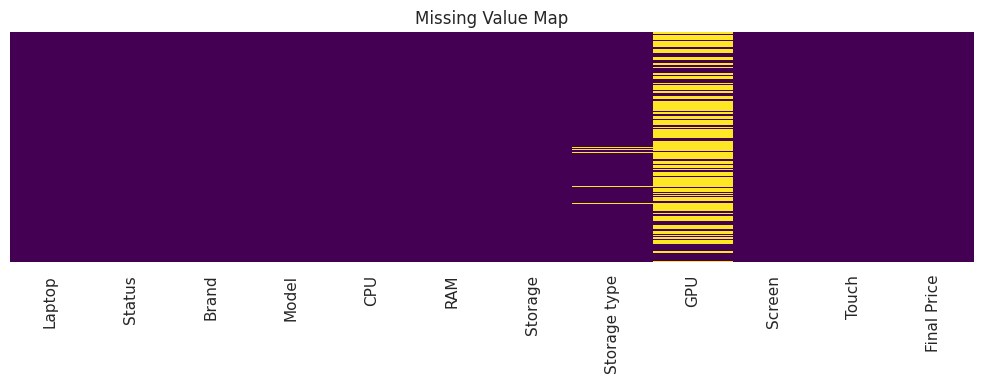

Fully duplicated rows: 0
['laptop', 'status', 'brand', 'model', 'cpu', 'ram', 'storage', 'storage_type', 'gpu', 'screen', 'touch', 'final_price']
Remaining missing values:
 laptop          0
status          0
brand           0
model           0
cpu             0
ram             0
storage         0
storage_type    0
gpu             0
screen          0
touch           0
final_price     0
dtype: int64
               ram      storage       screen  final_price
count  2160.000000  2160.000000  2160.000000  2160.000000
mean     15.413889   596.294444    15.168912  1312.638509
std       9.867815   361.220506     1.202357   911.475417
min       4.000000     0.000000    10.100000   201.050000
25%       8.000000   256.000000    14.000000   661.082500
50%      16.000000   512.000000    15.600000  1031.945000
75%      16.000000  1000.000000    15.600000  1708.970000
max     128.000000  4000.000000    18.000000  7150.470000
Rows with storage == 0: 1
Saved -> data/laptops_cleaned.csv | shape: (2160, 

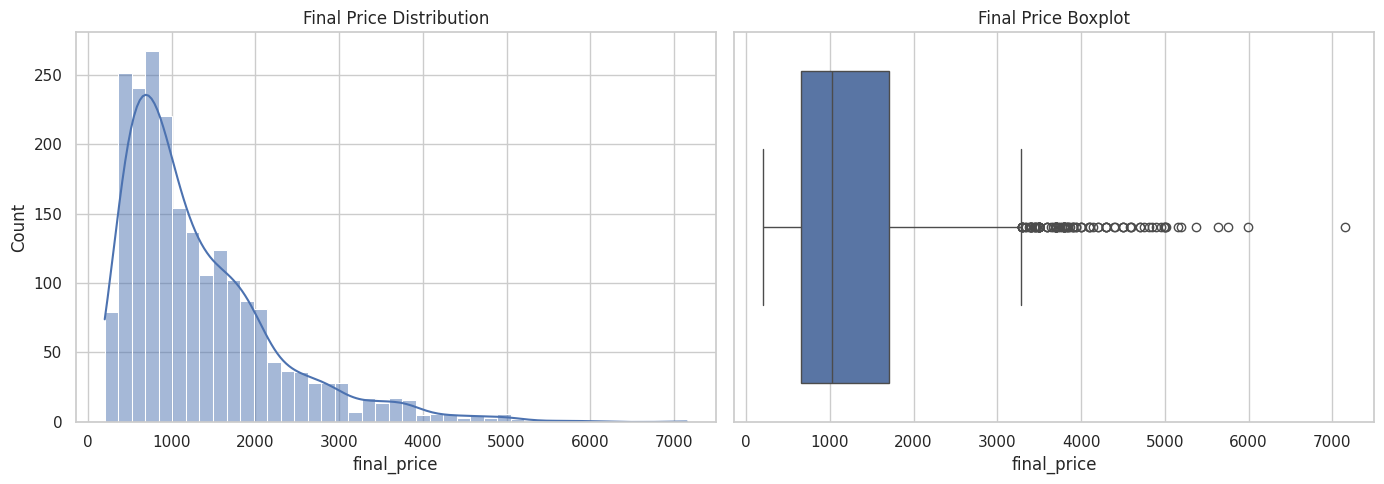

Skewness: 1.65
Min/Max: 201.05 7150.47


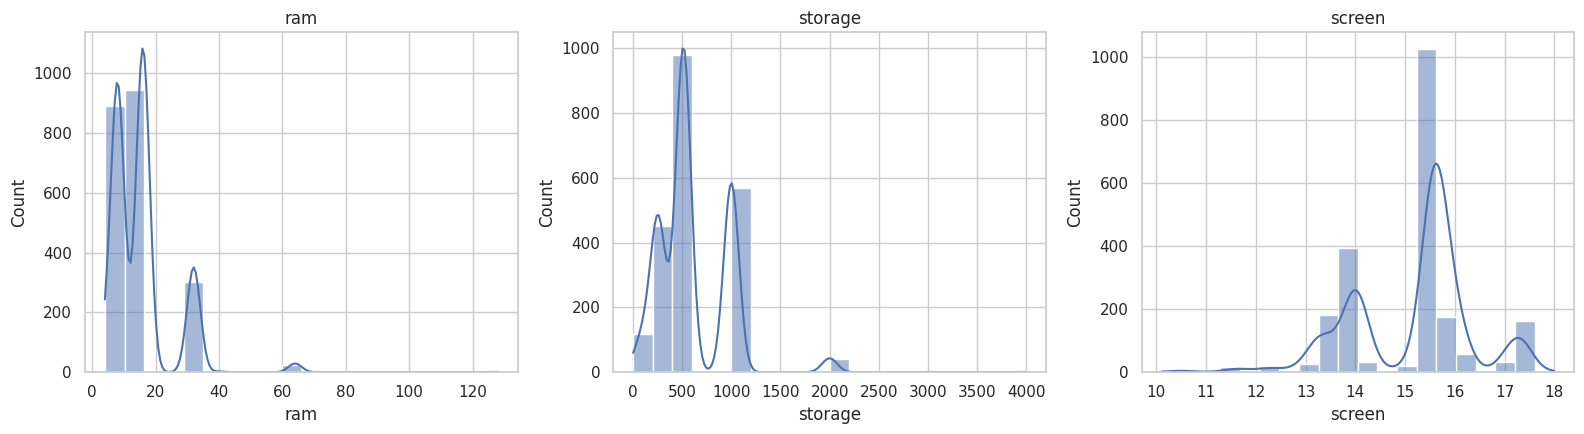

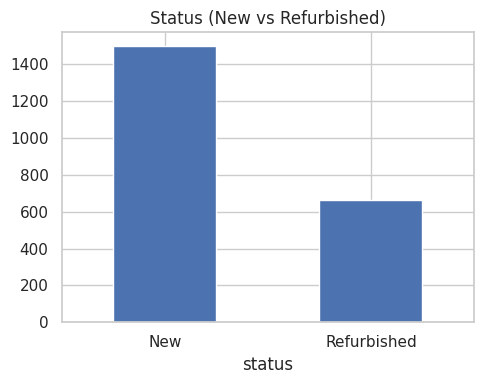

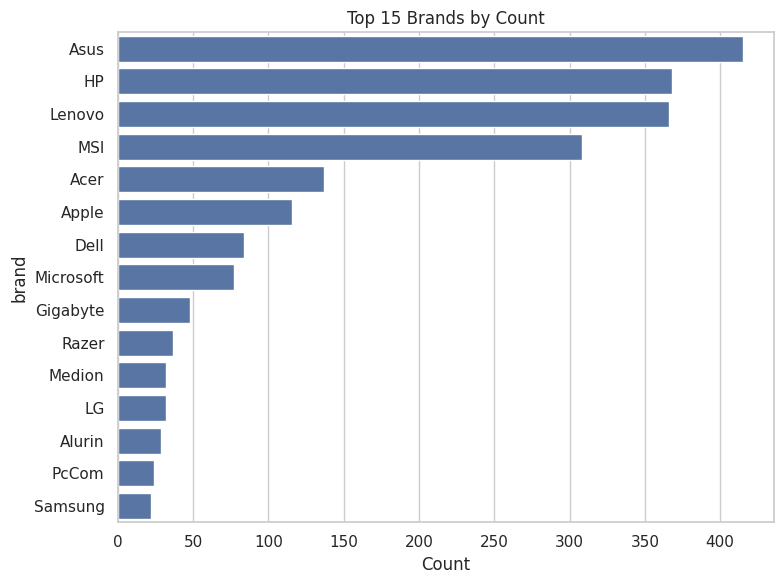

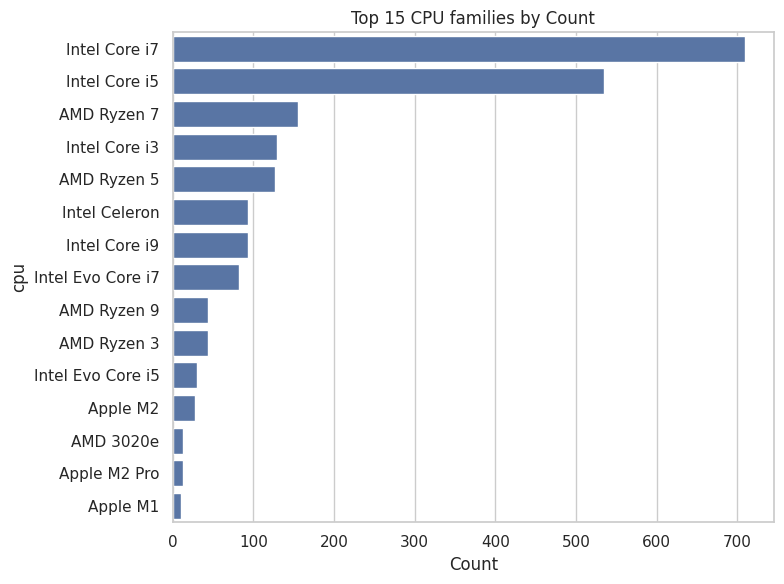

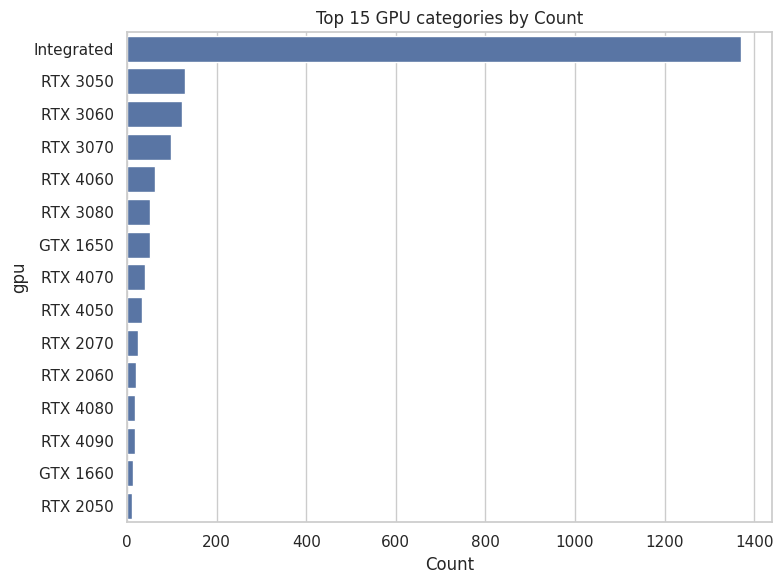

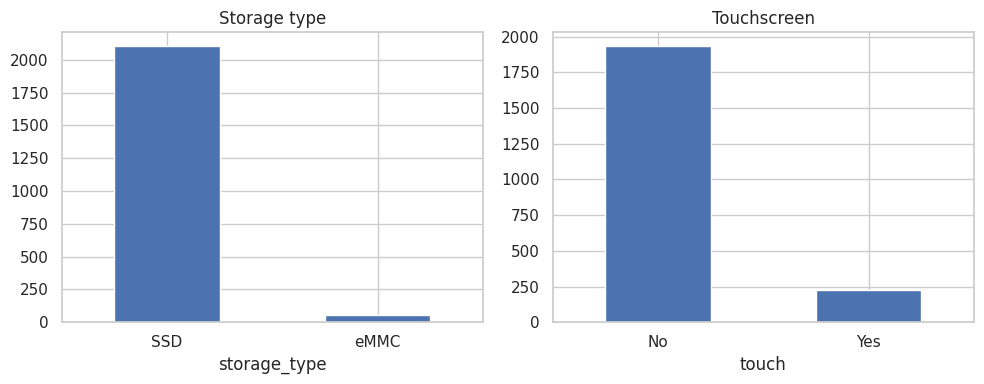

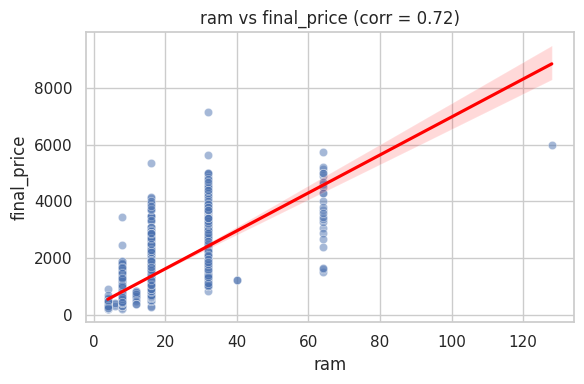

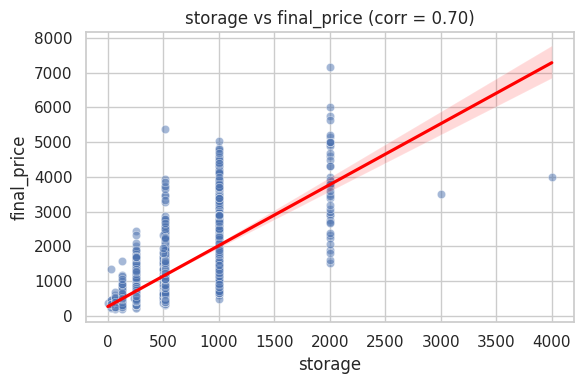

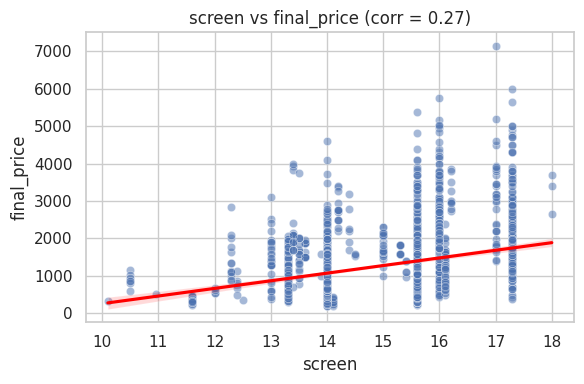

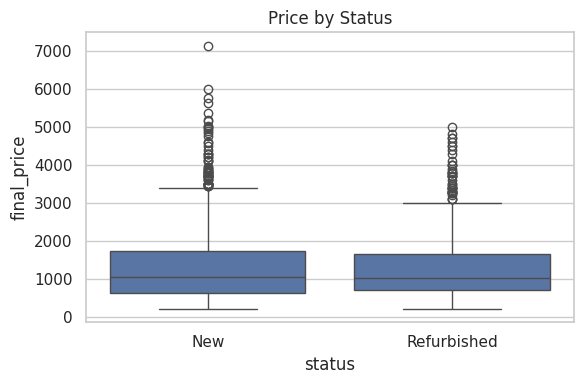

status
New            1039.775
Refurbished    1025.145
Name: final_price, dtype: float64


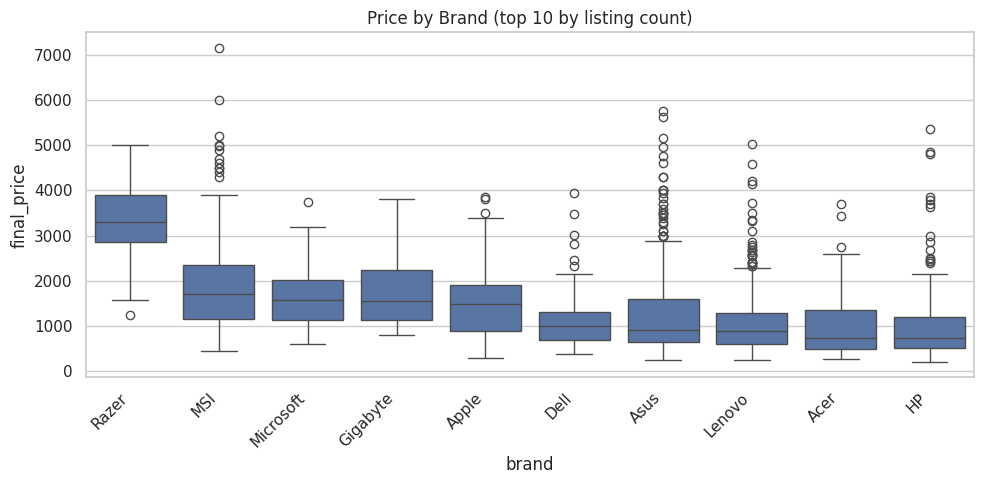

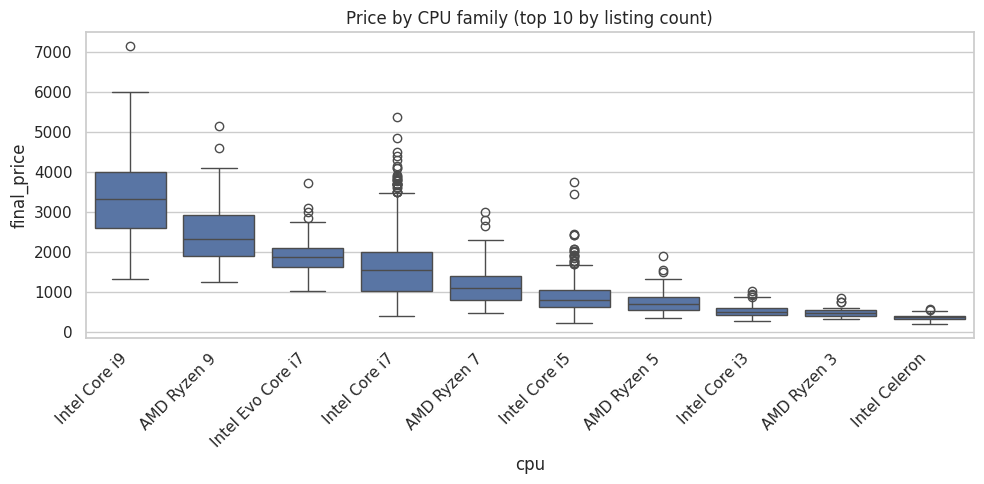

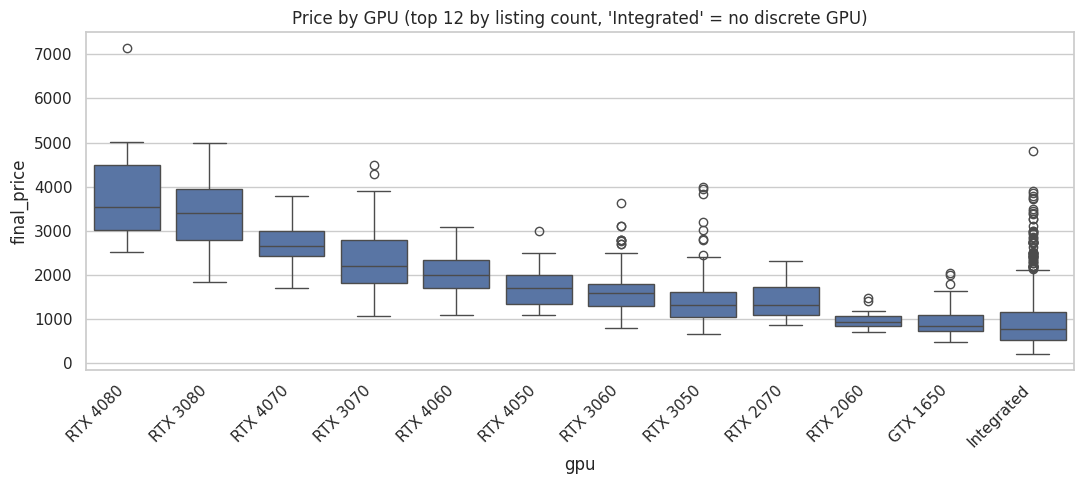

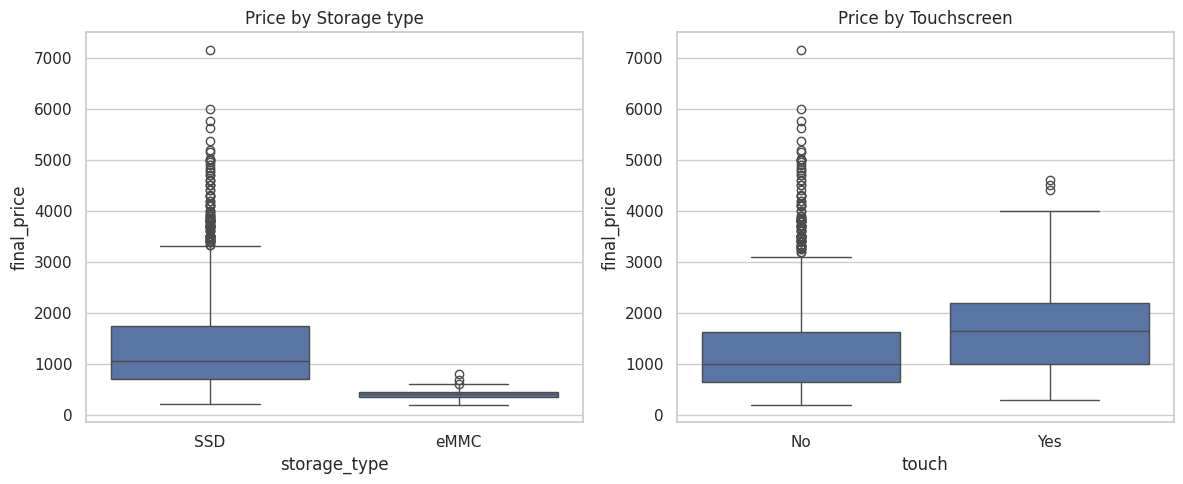

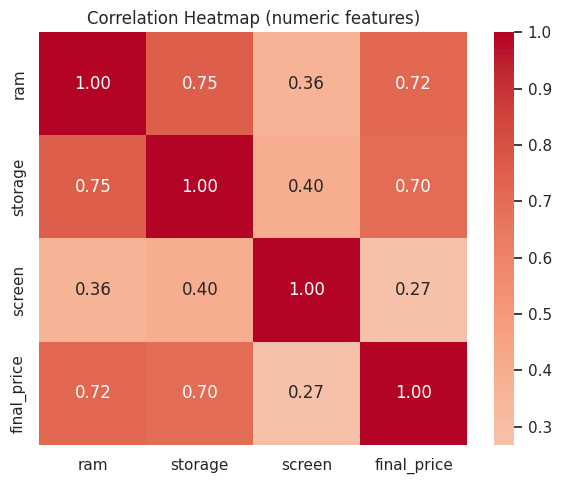

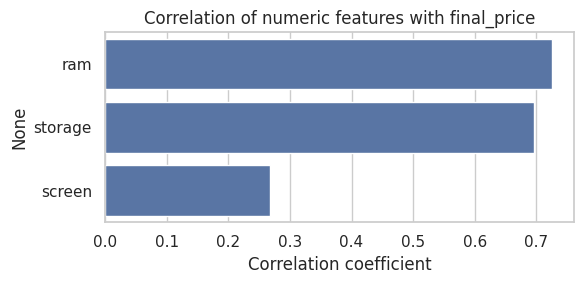

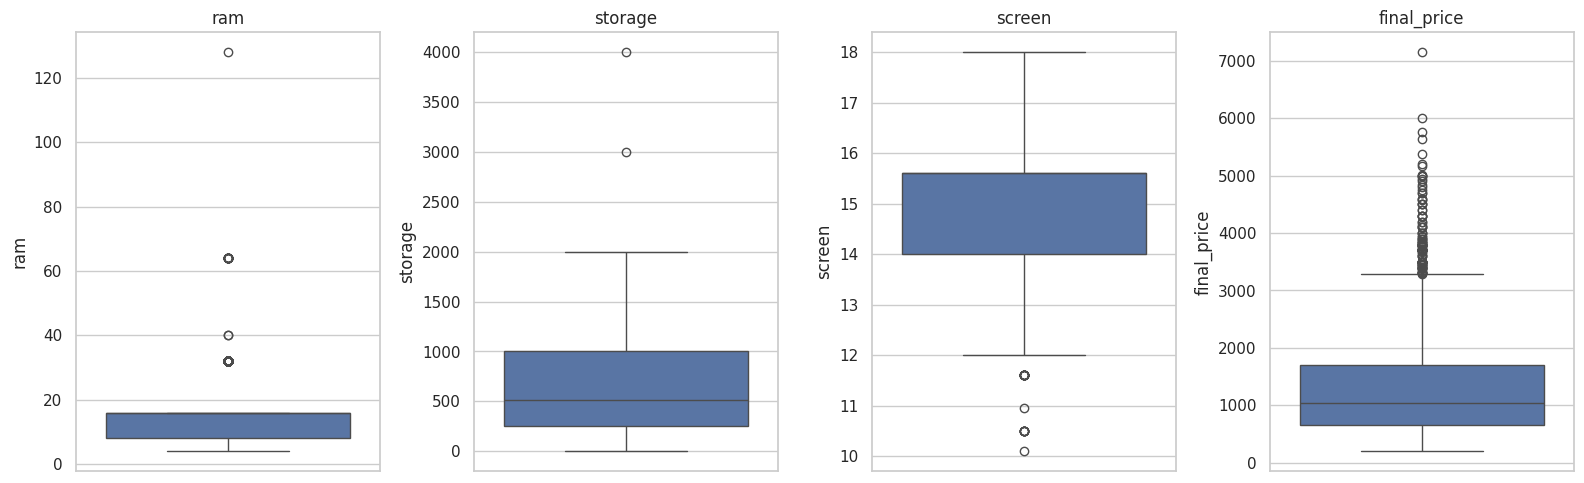

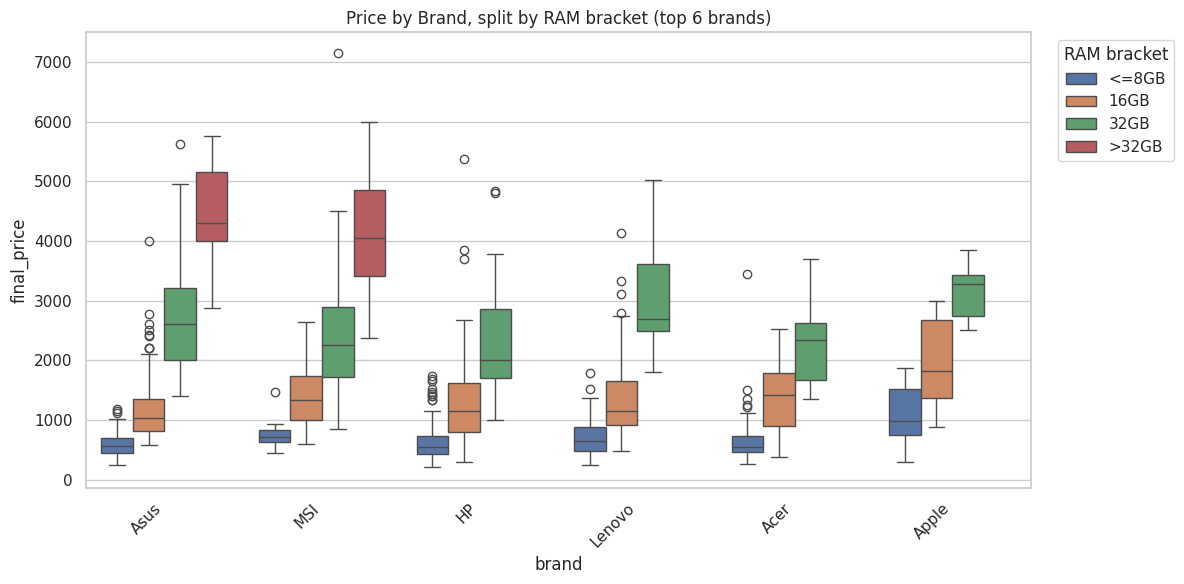

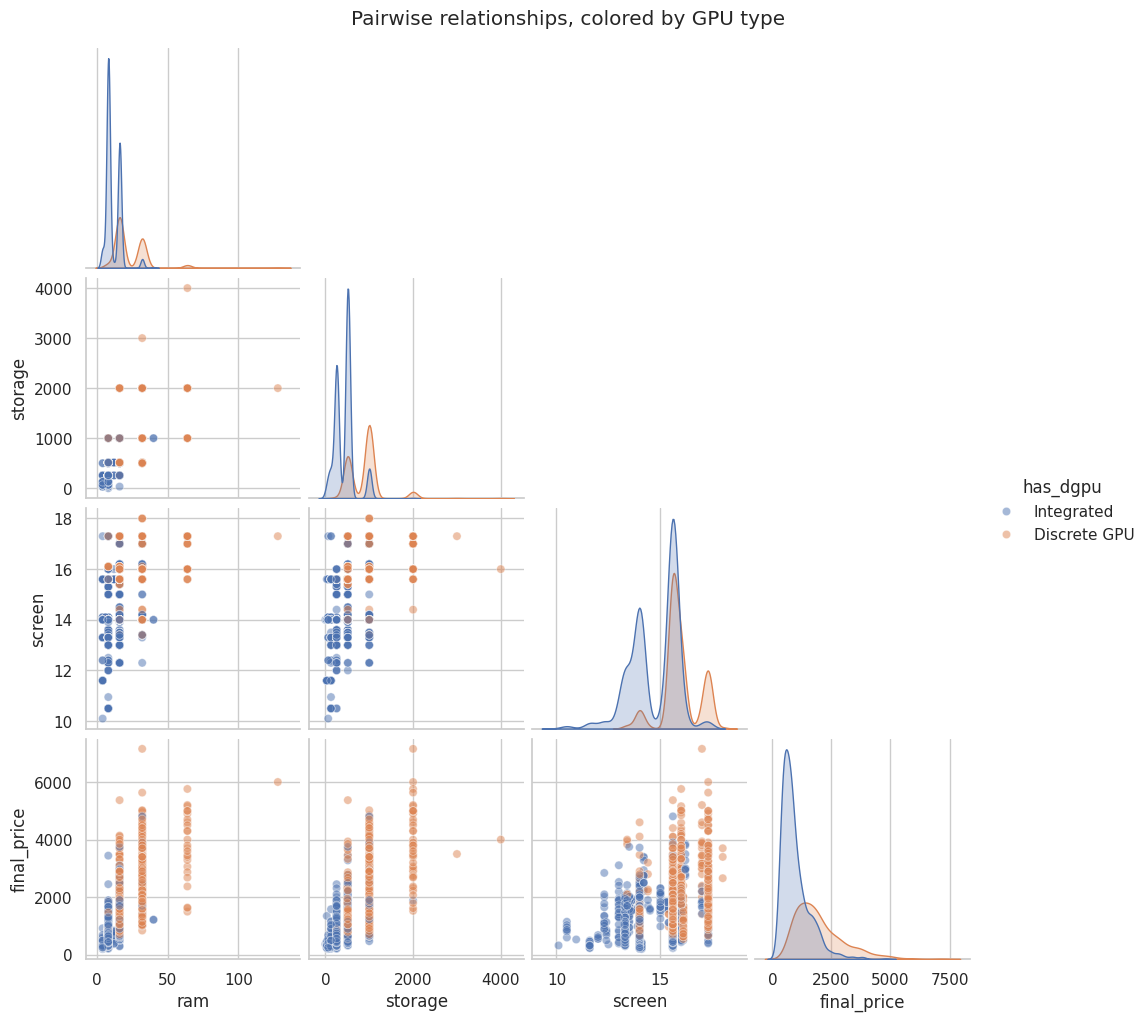

In [ ]:
# Colab setup: uncomment the line below on first run
# !pip install pandas numpy matplotlib seaborn -q

# Also upload laptops.csv to Colab (left sidebar -> Files -> upload),
# or mount Google Drive, then set the path below to match.

# %%

# # Intelligent Laptop Price Prediction — Exploratory Data Analysis (EDA)
#
# **Course:** BASCE301 — Exploratory Data Analysis
# **Team:** Aarav Sijariya (25BDS0058) · Sulagna Chowdhury (25BCE0979) · Tejaswini Jaiswal (25BDS0054)
# **Guide:** Padma Priya M
# **Dataset:** `laptops.csv` (2160 laptops, 12 columns) — Kaggle "Laptops Price Dataset"
#
# This notebook implements **Stage 1 (Data Foundation)** of the project workflow:
#
# `Dataset Collection → Data Cleaning → Exploratory Data Analysis`
#
# Columns in this dataset: `Laptop, Status, Brand, Model, CPU, RAM, Storage, Storage type, GPU,
# Screen, Touch, Final Price`.
#
# Sections:
# 1. Setup & Data Loading
# 2. Initial Inspection
# 3. Data Cleaning
# 4. Univariate Analysis
# 5. Bivariate Analysis (specs vs price)
# 6. Correlation Analysis
# 7. Outlier Detection
# 8. Multivariate / Grouped Analysis
# 9. Key EDA Insights Summary
# 10. Next Steps
#

# %%

# ## 1. Setup & Data Loading

# %%

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import files
uploaded = files.upload()   # opens a picker, choose laptops.csv
uploaded_file_name = list(uploaded.keys())[0]
df = pd.read_csv(uploaded_file_name)   # Use the name of the actually uploaded file
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

# %%

# The following lines are removed as they are redundant and use an incorrect path for loading the data.
# df = pd.read_csv("Internal Storage/Download/laptops.csv/Lap.csv")
# print("Shape:", df.shape)
# df.head()

# %%

# ## 2. Initial Inspection

# %%

df.info()

# %%

df.describe(include="all").T

# %%

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_df

# %%

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Value Map")
plt.tight_layout()
plt.show()

# %%

print("Fully duplicated rows:", df.duplicated().sum())

# %%

# **Observations from this dataset:**
# - No duplicate rows.
# - `Storage type` missing for 42 rows (~2%).
# - `Screen` missing for 4 rows (~0.2%) — safe to impute with median.
# - `GPU` missing for **1,371 rows (~63%)** — this is almost certainly *not* random missingness.
#   Laptops without a discrete GPU field are very likely running **integrated graphics**
#   (built into the CPU), so this should be encoded as a category (`"Integrated"`), not imputed
#   with mean/mode or dropped.
#

# %%

# ## 3. Data Cleaning

# %%

df_clean = df.copy()

# Standardize column names: lowercase, snake_case
df_clean.columns = (
    df_clean.columns.str.strip().str.lower().str.replace(" ", "_")
)
print(df_clean.columns.tolist())

# %%

# GPU: missing = integrated graphics, not truly "unknown"
df_clean["gpu"] = df_clean["gpu"].fillna("Integrated")

# Storage type: impute the small number of missing values with the mode (SSD)
df_clean["storage_type"] = df_clean["storage_type"].fillna(df_clean["storage_type"].mode().iloc[0])

# Screen: impute the 4 missing values with the median screen size
df_clean["screen"] = df_clean["screen"].fillna(df_clean["screen"].median())

print("Remaining missing values:\n", df_clean.isnull().sum())

# %%

# Standardize categorical text (trim whitespace)
cat_cols_all = df_clean.select_dtypes(include="object").columns
for c in cat_cols_all:
    df_clean[c] = df_clean[c].astype(str).str.strip()

# Sanity check ranges
print(df_clean[["ram", "storage", "screen", "final_price"]].describe())

# %%

# Storage == 0 check (does 0 mean "no storage listed" / possible data issue?)
print("Rows with storage == 0:", (df_clean["storage"] == 0).sum())
df_clean[df_clean["storage"] == 0][["laptop", "brand", "storage", "storage_type", "final_price"]].head()

# %%

# Rename target for convenience
PRICE_COL = "final_price"

# Save cleaned dataset
import os
os.makedirs("data", exist_ok=True)
df_clean.to_csv("data/laptops_cleaned.csv", index=False)
print("Saved -> data/laptops_cleaned.csv | shape:", df_clean.shape)

# %%

# ## 4. Univariate Analysis

# %%

num_cols = ["ram", "storage", "screen", "final_price"]
cat_cols = ["status", "brand", "cpu", "storage_type", "gpu", "touch"]

# %%

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean[PRICE_COL], kde=True, ax=axes[0])
axes[0].set_title("Final Price Distribution")
sns.boxplot(x=df_clean[PRICE_COL], ax=axes[1])
axes[1].set_title("Final Price Boxplot")
plt.tight_layout()
plt.show()

print("Skewness:", df_clean[PRICE_COL].skew().round(2))
print("Min/Max:", df_clean[PRICE_COL].min(), df_clean[PRICE_COL].max())

# %%

other_num = ["ram", "storage", "screen"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, c in zip(axes, other_num):
    sns.histplot(df_clean[c], kde=True, ax=ax, bins=20)
    ax.set_title(c)
plt.tight_layout()
plt.show()

# %%

# Status
plt.figure(figsize=(5, 4))
df_clean["status"].value_counts().plot(kind="bar")
plt.title("Status (New vs Refurbished)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# %%

# Brand (top 15)
top_brands = df_clean["brand"].value_counts().head(15)
plt.figure(figsize=(8, 6))
sns.barplot(x=top_brands.values, y=top_brands.index, orient="h")
plt.title("Top 15 Brands by Count")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

# %%

# CPU family (top 15)
top_cpu = df_clean["cpu"].value_counts().head(15)
plt.figure(figsize=(8, 6))
sns.barplot(x=top_cpu.values, y=top_cpu.index, orient="h")
plt.title("Top 15 CPU families by Count")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

# %%

# GPU (top 15, including 'Integrated')
top_gpu = df_clean["gpu"].value_counts().head(15)
plt.figure(figsize=(8, 6))
sns.barplot(x=top_gpu.values, y=top_gpu.index, orient="h")
plt.title("Top 15 GPU categories by Count")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

# %%

# Storage type & Touch
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df_clean["storage_type"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Storage type")
axes[0].tick_params(axis='x', rotation=0)
df_clean["touch"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Touchscreen")
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# %%

# ## 5. Bivariate Analysis — Specs vs Final Price

# %%

for c in other_num:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df_clean[c], y=df_clean[PRICE_COL], alpha=0.5)
    sns.regplot(x=df_clean[c], y=df_clean[PRICE_COL], scatter=False, color="red")
    corr = df_clean[c].corr(df_clean[PRICE_COL])
    plt.title(f"{c} vs final_price (corr = {corr:.2f})")
    plt.tight_layout()
    plt.show()

# %%

# Price by Status (New vs Refurbished)
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_clean, x="status", y=PRICE_COL)
plt.title("Price by Status")
plt.tight_layout()
plt.show()

print(df_clean.groupby("status")[PRICE_COL].median())

# %%

# Price by Brand (top 10 brands by count, ordered by median price)
top10_brands = df_clean["brand"].value_counts().head(10).index
subset = df_clean[df_clean["brand"].isin(top10_brands)]
order = subset.groupby("brand")[PRICE_COL].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 5))
sns.boxplot(data=subset, x="brand", y=PRICE_COL, order=order)
plt.xticks(rotation=45, ha="right")
plt.title("Price by Brand (top 10 by listing count)")
plt.tight_layout()
plt.show()

# %%

# Price by CPU family (top 10)
top10_cpu = df_clean["cpu"].value_counts().head(10).index
subset = df_clean[df_clean["cpu"].isin(top10_cpu)]
order = subset.groupby("cpu")[PRICE_COL].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 5))
sns.boxplot(data=subset, x="cpu", y=PRICE_COL, order=order)
plt.xticks(rotation=45, ha="right")
plt.title("Price by CPU family (top 10 by listing count)")
plt.tight_layout()
plt.show()

# %%

# Price by GPU (top 12, including Integrated)
top_gpu12 = df_clean["gpu"].value_counts().head(12).index
subset = df_clean[df_clean["gpu"].isin(top_gpu12)]
order = subset.groupby("gpu")[PRICE_COL].median().sort_values(ascending=False).index

plt.figure(figsize=(11, 5))
sns.boxplot(data=subset, x="gpu", y=PRICE_COL, order=order)
plt.xticks(rotation=45, ha="right")
plt.title("Price by GPU (top 12 by listing count, 'Integrated' = no discrete GPU)")
plt.tight_layout()
plt.show()

# %%

# Price by Storage type & Touch
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_clean, x="storage_type", y=PRICE_COL, ax=axes[0])
axes[0].set_title("Price by Storage type")
sns.boxplot(data=df_clean, x="touch", y=PRICE_COL, ax=axes[1])
axes[1].set_title("Price by Touchscreen")
plt.tight_layout()
plt.show()

# %%

# ## 6. Correlation Analysis

# %%

plt.figure(figsize=(6, 5))
corr_matrix = df_clean[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (numeric features)")
plt.tight_layout()
plt.show()

# %%

price_corr = corr_matrix[PRICE_COL].drop(PRICE_COL).sort_values(ascending=False)
plt.figure(figsize=(6, 3))
sns.barplot(x=price_corr.values, y=price_corr.index)
plt.title(f"Correlation of numeric features with {PRICE_COL}")
plt.xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()
price_corr

# %%

# ## 7. Outlier Detection (IQR method)

# %%

def iqr_outlier_summary(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((series < lower) | (series > upper)).sum()
    return lower, upper, n_out

rows = []
for c in num_cols:
    lower, upper, n_out = iqr_outlier_summary(df_clean[c])
    rows.append({"column": c, "lower_bound": round(lower, 2), "upper_bound": round(upper, 2),
                 "n_outliers": n_out, "pct_outliers": round(n_out / len(df_clean) * 100, 2)})

outlier_summary = pd.DataFrame(rows).sort_values("pct_outliers", ascending=False)
outlier_summary

# %%

fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 5))
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df_clean[c], ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

# %%

# Inspect the most expensive laptops flagged as price outliers
q1, q3 = df_clean[PRICE_COL].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
df_clean[df_clean[PRICE_COL] > upper].sort_values(PRICE_COL, ascending=False)[
    ["laptop", "brand", "cpu", "ram", "storage", "gpu", PRICE_COL]
].head(15)

# %%

# ## 8. Multivariate / Grouped Analysis

# %%

pivot = df_clean.groupby("brand")[PRICE_COL].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
pivot.head(15)

# %%

# Brand x RAM bracket interaction (top 6 brands by count)
top6_brands = df_clean["brand"].value_counts().head(6).index
subset = df_clean[df_clean["brand"].isin(top6_brands)].copy()
subset["ram_bracket"] = pd.cut(subset["ram"], bins=[0, 8, 16, 32, 200],
                                labels=["<=8GB", "16GB", "32GB", ">32GB"])

plt.figure(figsize=(12, 6))
sns.boxplot(data=subset, x="brand", y=PRICE_COL, hue="ram_bracket")
plt.xticks(rotation=45, ha="right")
plt.title("Price by Brand, split by RAM bracket (top 6 brands)")
plt.legend(title="RAM bracket", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# %%

# Pairplot across numeric features, colored by has-discrete-GPU
plot_df = df_clean.copy()
plot_df["has_dgpu"] = np.where(plot_df["gpu"] == "Integrated", "Integrated", "Discrete GPU")
sns.pairplot(plot_df[num_cols + ["has_dgpu"]], hue="has_dgpu", corner=True, plot_kws={"alpha": 0.5})
plt.suptitle("Pairwise relationships, colored by GPU type", y=1.02)
plt.show()

# %%

# ## 9. Key EDA Insights Summary
#
# - **Dataset:** 2,160 laptops, 12 columns, **no duplicate rows**. `GPU` missing for ~63.5%
#   of rows — reinterpreted as **"Integrated graphics"** rather than true missing data (a
#   domain-knowledge call, not a mechanical imputation). `Storage type` (42 rows) and `Screen`
#   (4 rows) had small genuine gaps, filled with mode/median.
# - **Price distribution:** right-skewed, **skewness ≈ 1.65**, ranging **$201 – $7,150**,
#   median ≈ **$1,032** vs mean ≈ **$1,313** — the gap between mean and median confirms a
#   long tail of premium/workstation laptops pulling the average up.
# - **Strongest numeric drivers of price:** RAM (corr ≈ **0.72**) and Storage (corr ≈ **0.70**)
#   are the strongest numeric predictors; Screen size is only weakly correlated (≈ **0.27**).
# - **Discrete GPU premium:** laptops with a discrete GPU have a median price of
#   **≈ $1,699**, more than **2x** the **≈ $770** median for integrated-graphics laptops —
#   GPU tier should be a first-class categorical feature going forward.
# - **Brand effect:** **Razer** has by far the highest median price (≈ **$3,300**), followed
#   by Millenium, LG, MSI, PcCom; budget brands like **Prixton, Primux, Thomson** sit near
#   **$300–330** median — a >10x brand-driven spread even before controlling for specs.
# - **CPU family effect:** higher-tier chips (Core i9/i7, Ryzen 9/7, Apple M-series)
#   associate with markedly higher prices than entry-level chips (Celeron, low-end Ryzen 3).
# - **Refurbished vs New:** median price is very close (New ≈ **$1,040** vs Refurbished ≈
#   **$1,025**) — smaller effect than expected, likely because refurbished listings skew
#   toward higher-spec machines being resold. Worth a closer look with specs held constant.
# - **Outliers:** **103 laptops (≈4.8%)** sit above the IQR upper bound (~$3,281) on price —
#   inspection shows these are legitimate high-RAM / top-tier-GPU / workstation-class models,
#   not data-entry errors, so they are flagged rather than removed.
# - **Multicollinearity note:** RAM and Storage move together to some extent (both scale up
#   together in higher-end configs) — worth watching during feature selection /
#   regularization in the modeling phase.
#

# %%

# ## 10. Next Steps (beyond this notebook)
#
# 1. **Feature Engineering** — encode `has_discrete_gpu`, GPU tier buckets, CPU tier buckets,
#    `price_per_gb_ram`, etc.
# 2. **Encoding & Scaling** — one-hot/target encode `brand`, `cpu`, `gpu`, `storage_type`;
#    scale numeric features.
# 3. **Modeling** — Linear Regression, Random Forest, Gradient Boosting/XGBoost (80/20 split,
#    cross-validation).
# 4. **Evaluation** — MAE, RMSE, R².
# 5. **Explainability & Fair-Value Analysis** — SHAP feature importance, then compare predicted
#    "fair price" to `final_price` to flag under/over-pricing.
#
# These stages belong in a separate `02_feature_engineering_modeling.ipynb` notebook.
#

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/laptops_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2160, 12)


,laptop,status,brand,model,cpu,ram,storage,storage_type,gpu,screen,touch,final_price
0,ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core...,New,Asus,ExpertBook,Intel Core i5,8,512,SSD,Integrated,15.6,No,1009.00
1,Alurin Go Start Intel Celeron N4020/8GB/256GB ...,New,Alurin,Go,Intel Celeron,8,256,SSD,Integrated,15.6,No,299.00
2,ASUS ExpertBook B1 B1502CBA-EJ0424X Intel Core...,New,Asus,ExpertBook,Intel Core i3,8,256,SSD,Integrated,15.6,No,789.00
3,MSI Katana GF66 12UC-082XES Intel Core i7-1270...,New,MSI,Katana,Intel Core i7,16,1000,SSD,RTX 3050,15.6,No,1199.00
4,HP 15S-FQ5085NS Intel Core i5-1235U/16GB/512GB...,New,HP,15S,Intel Core i5,16,512,SSD,Integrated,15.6,No,669.01


In [ ]:
print("CPU values:")
print(df["cpu"].value_counts().head(20))

print("\nGPU values:")
print(df["gpu"].value_counts().head(20))

print("\nBrands:")
print(df["brand"].value_counts().head(20))

print("\nStorage types:")
print(df["storage_type"].value_counts())

print("\nTouch:")
print(df["touch"].value_counts())

print("\nStatus:")
print(df["status"].value_counts())

CPU values:
cpu
Intel Core i7            710
Intel Core i5            535
AMD Ryzen 7              156
Intel Core i3            130
AMD Ryzen 5              127
Intel Celeron             94
Intel Core i9             94
Intel Evo Core i7         82
AMD Ryzen 9               44
AMD Ryzen 3               44
Intel Evo Core i5         30
Apple M2                  28
AMD 3020e                 13
Apple M2 Pro              13
Apple M1                  11
AMD Athlon                10
Intel Pentium             10
Apple M1 Pro               7
Intel Core M3              5
Qualcomm Snapdragon 7      3
Name: count, dtype: int64

GPU values:
gpu
Integrated          1371
RTX 3050             129
RTX 3060             122
RTX 3070              97
RTX 4060              62
RTX 3080              51
GTX 1650              50
RTX 4070              40
RTX 4050              33
RTX 2070              25
RTX 2060              20
RTX 4080              18
RTX 4090              17
GTX 1660              14
RTX 2050   

In [ ]:
# Create a copy so the original cleaned dataframe remains unchanged
df_fe = df.copy()

# Rename numerical hardware features for clarity
df_fe["ram_gb"] = df_fe["ram"]
df_fe["storage_gb"] = df_fe["storage"]
df_fe["screen_size"] = df_fe["screen"]

# Binary features
df_fe["is_ssd"] = (df_fe["storage_type"] == "SSD").astype(int)
df_fe["is_touch"] = (df_fe["touch"] == "Yes").astype(int)
df_fe["is_new"] = (df_fe["status"] == "New").astype(int)

# Discrete GPU indicator
df_fe["has_discrete_gpu"] = (
    df_fe["gpu"] != "Integrated"
).astype(int)

print("New features created:")
print(df_fe.columns.tolist())

New features created:
['laptop', 'status', 'brand', 'model', 'cpu', 'ram', 'storage', 'storage_type', 'gpu', 'screen', 'touch', 'final_price', 'ram_gb', 'storage_gb', 'screen_size', 'is_ssd', 'is_touch', 'is_new', 'has_discrete_gpu']


In [ ]:
def get_cpu_brand(cpu):
    cpu = str(cpu)

    if cpu.startswith("Intel"):
        return "Intel"
    elif cpu.startswith("AMD"):
        return "AMD"
    elif cpu.startswith("Apple"):
        return "Apple"
    elif cpu.startswith("Qualcomm"):
        return "Qualcomm"
    else:
        return "Other"


def get_cpu_tier(cpu):
    cpu = str(cpu)

    # High-end
    if "Core i9" in cpu or "Ryzen 9" in cpu or "M2 Pro" in cpu or "M1 Pro" in cpu:
        return "High"

    # Upper-mid
    elif "Core i7" in cpu or "Ryzen 7" in cpu or "M2" in cpu or "M1" in cpu:
        return "Upper-Mid"

    # Mid-range
    elif "Core i5" in cpu or "Ryzen 5" in cpu:
        return "Mid"

    # Entry-mid
    elif "Core i3" in cpu or "Ryzen 3" in cpu:
        return "Entry-Mid"

    # Entry-level
    elif (
        "Celeron" in cpu
        or "Pentium" in cpu
        or "Athlon" in cpu
        or "3020e" in cpu
        or "Core M3" in cpu
        or "Snapdragon" in cpu
    ):
        return "Entry"

    else:
        return "Other"


df_fe["cpu_brand"] = df_fe["cpu"].apply(get_cpu_brand)
df_fe["cpu_tier"] = df_fe["cpu"].apply(get_cpu_tier)

print("CPU Brand:")
print(df_fe["cpu_brand"].value_counts())

print("\nCPU Tier:")
print(df_fe["cpu_tier"].value_counts())

CPU Brand:
cpu_brand
Intel       1691
AMD          401
Apple         59
Qualcomm       5
Other          4
Name: count, dtype: int64

CPU Tier:
cpu_tier
Upper-Mid    987
Mid          692
Entry-Mid    174
High         159
Entry        137
Other         11
Name: count, dtype: int64


In [ ]:
def get_gpu_brand(gpu):
    gpu = str(gpu)

    if gpu == "Integrated":
        return "Integrated"
    elif gpu.startswith("RTX") or gpu.startswith("GTX") or gpu.startswith("MX"):
        return "NVIDIA"
    elif "Radeon" in gpu:
        return "AMD"
    else:
        return "Other"


df_fe["gpu_brand"] = df_fe["gpu"].apply(get_gpu_brand)

print(df_fe["gpu_brand"].value_counts())

gpu_brand
Integrated    1371
NVIDIA         743
Other           31
AMD             15
Name: count, dtype: int64


In [ ]:
feature_columns = [
    "brand",
    "cpu",
    "cpu_brand",
    "cpu_tier",
    "ram_gb",
    "storage_gb",
    "storage_type",
    "is_ssd",
    "gpu",
    "gpu_brand",
    "has_discrete_gpu",
    "screen_size",
    "is_touch",
    "is_new",
    "final_price"
]

df_fe[feature_columns].head(10)

print("Shape:", df_fe.shape)
print("\nMissing values:")
print(df_fe[feature_columns].isnull().sum())

Shape: (2160, 22)

Missing values:
brand               0
cpu                 0
cpu_brand           0
cpu_tier            0
ram_gb              0
storage_gb          0
storage_type        0
is_ssd              0
gpu                 0
gpu_brand           0
has_discrete_gpu    0
screen_size         0
is_touch            0
is_new              0
final_price         0
dtype: int64


In [ ]:
# Features used for machine learning

categorical_features = [
    "brand",
    "cpu",
    "gpu",
    "storage_type",
    "status",
    "touch"
]

numerical_features = [
    "ram_gb",
    "storage_gb",
    "screen_size",
    "is_ssd",
    "is_touch",
    "is_new",
    "has_discrete_gpu"
]

feature_columns = categorical_features + numerical_features

X = df_fe[feature_columns]
y = df_fe["final_price"]

print("Features used:", feature_columns)
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features used: ['brand', 'cpu', 'gpu', 'storage_type', 'status', 'touch', 'ram_gb', 'storage_gb', 'screen_size', 'is_ssd', 'is_touch', 'is_new', 'has_discrete_gpu']

X shape: (2160, 13)
y shape: (2160,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1728, 13)
Testing set: (432, 13)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## Model Training

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


In [ ]:
from sklearn.pipeline import Pipeline

# 1. Linear Regression
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# 2. Random Forest
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# 3. XGBoost
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                random_state=42,
                n_jobs=-1,
                objective="reg:squarederror"
            )
        )
    ]
)

print("All three model pipelines created successfully.")

All three model pipelines created successfully.


In [ ]:
print("Training Linear Regression...")
linear_model.fit(X_train, y_train)

print("Training Random Forest...")
random_forest_model.fit(X_train, y_train)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

print("\nAll models trained successfully!")

Training Linear Regression...
Training Random Forest...
Training XGBoost...

All models trained successfully!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    return mae, rmse, r2

    # Evaluate all models

linear_mae, linear_rmse, linear_r2 = evaluate_model(
    linear_model, X_test, y_test
)

rf_mae, rf_rmse, rf_r2 = evaluate_model(
    random_forest_model, X_test, y_test
)

xgb_mae, xgb_rmse, xgb_r2 = evaluate_model(
    xgb_model, X_test, y_test
)
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        xgb_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,260.821099,390.126877,0.834948
1,Random Forest,263.281431,447.637407,0.782699
2,XGBoost,259.839699,419.303926,0.809337


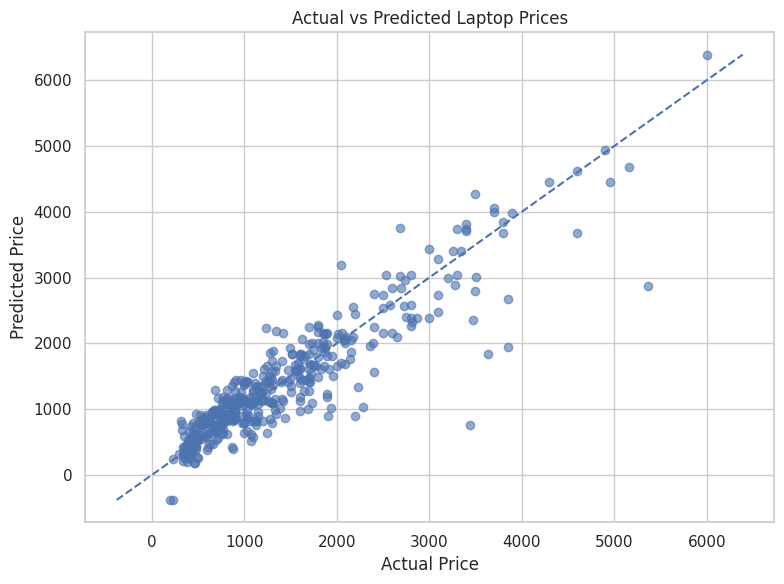

In [ ]:
import matplotlib.pyplot as plt

# Predictions from the best model
y_pred_lr = linear_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_lr, alpha=0.6)

# Perfect prediction line
min_price = min(y_test.min(), y_pred_lr.min())
max_price = max(y_test.max(), y_pred_lr.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Laptop Prices")

plt.tight_layout()
plt.show()

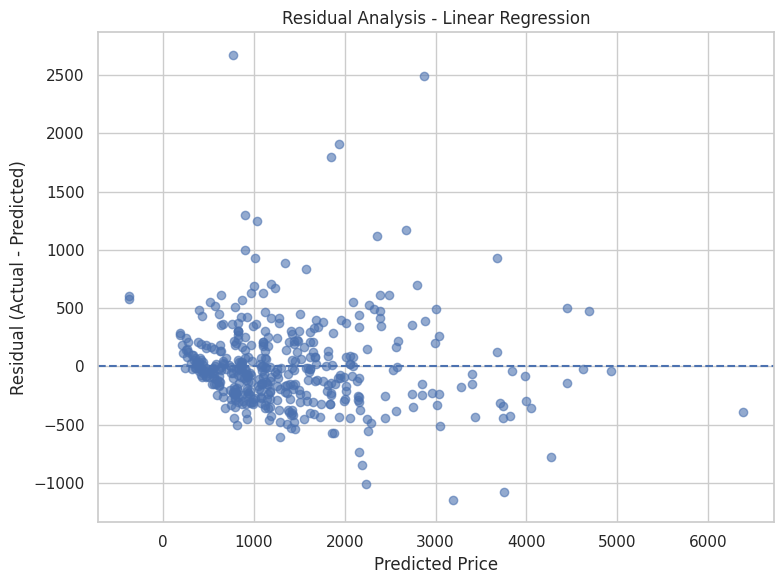

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Residuals
residuals = y_test - y_pred_lr

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_lr, residuals, alpha=0.6)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis - Linear Regression")

plt.tight_layout()
plt.show()

             Feature  Importance
2                gpu    0.378622
1                cpu    0.138272
6             ram_gb    0.097574
0              brand    0.070543
7         storage_gb    0.041735
10          is_touch    0.019563
11            is_new    0.013751
8        screen_size    0.003048
4             status    0.000774
9             is_ssd    0.000687
5              touch    0.000320
3       storage_type    0.000010
12  has_discrete_gpu   -0.000173


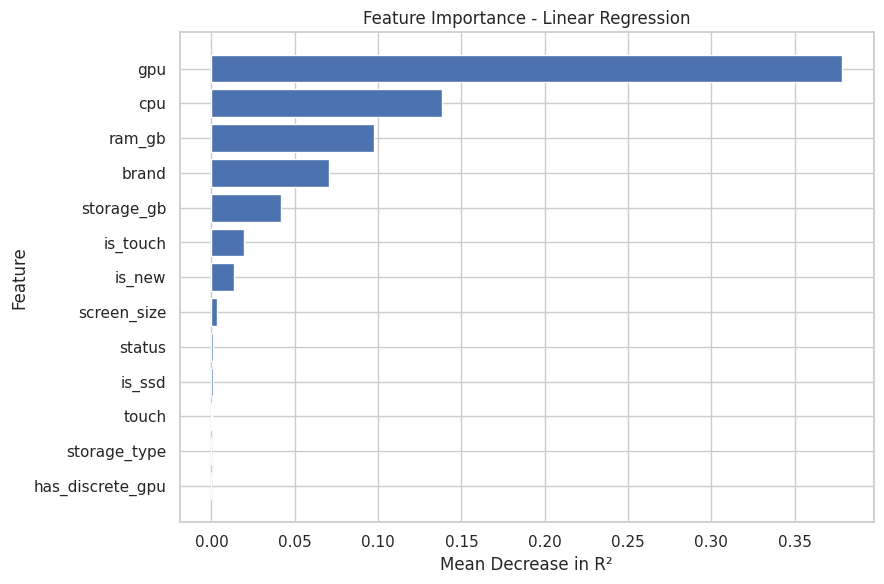

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Calculate permutation importance on the test set
perm_importance = permutation_importance(
    linear_model,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create importance dataframe
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

# Plot
plt.figure(figsize=(9, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Mean Decrease in R²")
plt.ylabel("Feature")
plt.title("Feature Importance - Linear Regression")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

SHAP values calculated successfully!
Number of features: 104


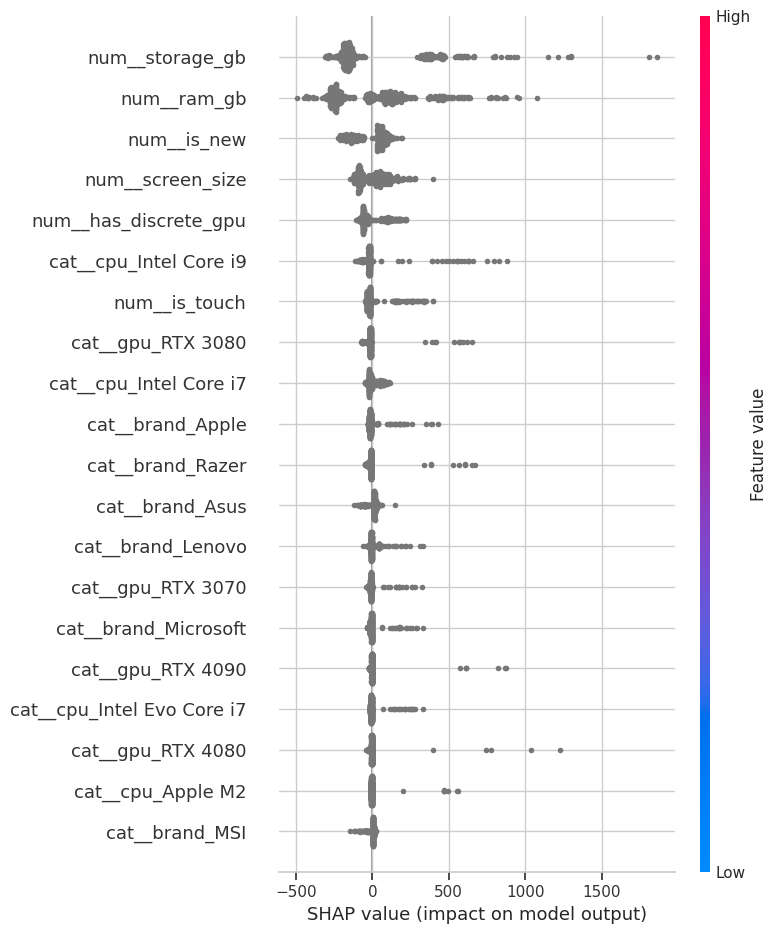

In [ ]:
# Install SHAP if needed
!pip install shap -q

import shap

# Transform the test data using the fitted preprocessor
X_test_transformed = xgb_model.named_steps["preprocessor"].transform(X_test)

# Get feature names after preprocessing
feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(
    xgb_model.named_steps["model"]
)

shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values calculated successfully!")
print("Number of features:", len(feature_names))

# SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=True
)

SHAP Explainability: SHAP analysis was used to understand the contribution of individual features to the XGBoost model's predictions. Storage capacity and RAM showed substantial influence, while high-performance CPU and GPU configurations produced strong positive contributions for several laptops. Specific GPU and CPU categories, as well as brand categories, also affected predicted prices. This provides instance-level interpretability beyond the overall model performance metrics.


In [ ]:
# Use the best-performing Linear Regression model
fair_price = linear_model.predict(X)

# Add predictions to the feature-engineered dataset
df_value = df_fe.copy()

df_value["fair_price"] = fair_price

# Difference between listed and predicted price
df_value["price_difference"] = (
    df_value["final_price"] - df_value["fair_price"]
)

# Percentage difference
df_value["price_difference_pct"] = (
    df_value["price_difference"] /
    df_value["fair_price"]
) * 100

df_value[[
    "brand",
    "cpu",
    "ram_gb",
    "storage_gb",
    "gpu",
    "final_price",
    "fair_price",
    "price_difference",
    "price_difference_pct"
]].head()

# Classify laptops based on a ±10% fair-price threshold

def classify_value(row):
    pct = row["price_difference_pct"]

    if pct < -10:
        return "Potentially Underpriced"
    elif pct <= 10:
        return "Fairly Priced"
    else:
        return "Potentially Overpriced"


df_value["value_category"] = df_value.apply(
    classify_value,
    axis=1
)

# View category counts
value_counts = df_value["value_category"].value_counts()

print(value_counts)

# Show percentages
value_percentages = (
    df_value["value_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nPercentage distribution:")
print(value_percentages)

value_category
Potentially Underpriced    823
Fairly Priced              720
Potentially Overpriced     617
Name: count, dtype: int64

Percentage distribution:
value_category
Potentially Underpriced    38.10
Fairly Priced              33.33
Potentially Overpriced     28.56
Name: proportion, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate
import pandas as pd

# Create Random Forest pipeline again
rf_cv_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Models for 5-fold cross-validation
models = {
    "Linear Regression": linear_model,
    "Random Forest": rf_cv_model,
    "XGBoost": xgb_model
}

cv_results = []

for name, model in models.items():

    print(f"Running 5-fold CV for {name}...")

    scores = cross_validate(
        model,
        X,
        y,
        cv=5,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R2": scores["test_R2"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

print("\n5-Fold Cross-Validation Results:")
display(cv_results_df.round(3))

Running 5-fold CV for Linear Regression...
Running 5-fold CV for Random Forest...
Running 5-fold CV for XGBoost...

5-Fold Cross-Validation Results:


,Model,CV MAE,CV RMSE,CV R2
0,Linear Regression,288.694,413.659,0.780
1,Random Forest,282.182,425.102,0.769
2,XGBoost,282.665,416.411,0.777


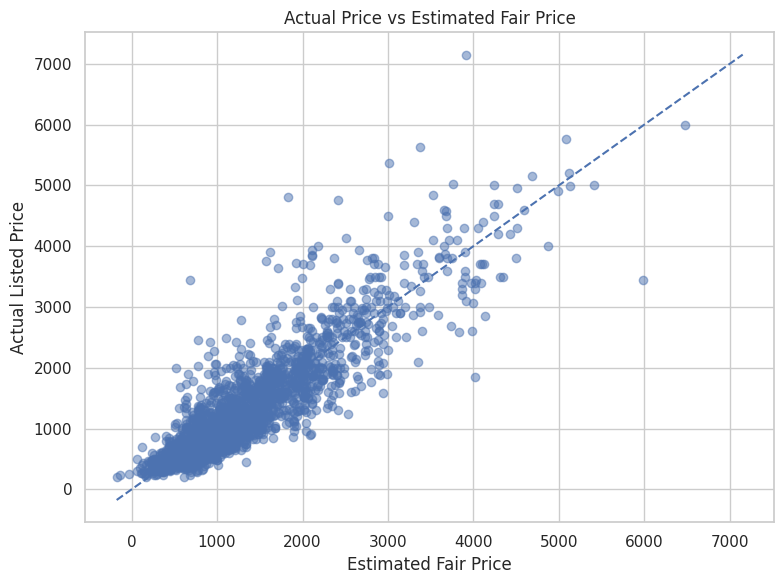

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df_value["fair_price"],
    df_value["final_price"],
    alpha=0.5
)

# Reference line: actual price = fair price
min_price = min(
    df_value["fair_price"].min(),
    df_value["final_price"].min()
)

max_price = max(
    df_value["fair_price"].max(),
    df_value["final_price"].max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Estimated Fair Price")
plt.ylabel("Actual Listed Price")
plt.title("Actual Price vs Estimated Fair Price")

plt.tight_layout()
plt.show()

Actual vs Estimated Fair Price: The scatter plot shows a clear positive relationship between listed price and model-estimated fair price. Many observations are concentrated around the reference line, indicating reasonable agreement between the two. However, deviations become more pronounced for some higher-priced laptops, reflecting greater uncertainty in estimating prices for high-end configurations.

In [ ]:
# Top 10 potentially underpriced laptops
top_underpriced = (
    df_value[df_value["value_category"] == "Potentially Underpriced"]
    .sort_values("price_difference")
    .head(10)
)

# Top 10 potentially overpriced laptops
top_overpriced = (
    df_value[df_value["value_category"] == "Potentially Overpriced"]
    .sort_values("price_difference", ascending=False)
    .head(10)
)

# Columns to display
display_columns = [
    "brand",
    "model",
    "cpu",
    "ram_gb",
    "storage_gb",
    "gpu",
    "final_price",
    "fair_price",
    "price_difference",
    "price_difference_pct",
    "value_category"
]

print("TOP 10 POTENTIALLY UNDERPRICED LAPTOPS")
display(
    top_underpriced[display_columns].round(2)
)

print("\nTOP 10 POTENTIALLY OVERPRICED LAPTOPS")
display(
    top_overpriced[display_columns].round(2)
)

TOP 10 POTENTIALLY UNDERPRICED LAPTOPS


,brand,model,cpu,ram_gb,storage_gb,gpu,final_price,fair_price,price_difference,price_difference_pct,value_category
1594,MSI,Creator,Intel Core i9,64,2000,RTX A5500,3448.42,5987.03,-2538.61,-42.40,Potentially Underpriced
2145,Razer,Blade,Intel Core i7,32,1000,RTX 3080,1848.14,4022.38,-2174.24,-54.05,Potentially Underpriced
146,MSI,Vector,Intel Core i9,32,1000,RTX 4080,2599.00,3988.89,-1389.89,-34.84,Potentially Underpriced
2153,Razer,Blade,Intel Core i7,16,512,RTX 3070,1583.39,2939.26,-1355.87,-46.13,Potentially Underpriced
2152,Razer,Blade,Intel Core i7,16,512,RTX 3060,1232.74,2532.96,-1300.22,-51.33,Potentially Underpriced
992,Asus,ProArt,Intel Core i7,32,1000,RTX A3000,2846.00,4136.49,-1290.49,-31.20,Potentially Underpriced
1778,Asus,ROG,AMD Ryzen 9,32,1000,RTX 3080,2099.00,3347.57,-1248.57,-37.30,Potentially Underpriced
1306,Acer,ConceptD,Intel Core i7,32,1000,RTX A3000,2595.00,3835.70,-1240.70,-32.35,Potentially Underpriced
2035,MSI,Leopard,Intel Core i7,16,1000,RTX 2070,901.09,2087.52,-1186.43,-56.83,Potentially Underpriced
1904,HP,Omen,Intel Core i7,16,1000,RTX 2070,911.84,2094.17,-1182.33,-56.46,Potentially Underpriced



TOP 10 POTENTIALLY OVERPRICED LAPTOPS


,brand,model,cpu,ram_gb,storage_gb,gpu,final_price,fair_price,price_difference,price_difference_pct,value_category
1099,MSI,Raider,Intel Core i9,32,2000,RTX 4080,7150.47,3914.63,3235.84,82.66,Potentially Overpriced
1925,HP,Zbook,Intel Core i9,32,1000,Integrated,4805.65,1828.99,2976.66,162.75,Potentially Overpriced
1284,Acer,Enduro,Intel Core i5,8,512,Integrated,3442.00,677.65,2764.35,407.93,Potentially Overpriced
1475,HP,Zbook,Intel Core i7,16,512,RTX A3000,5368.77,3013.70,2355.07,78.15,Potentially Overpriced
1203,Asus,ROG,AMD Radeon 9,32,1000,RTX 4080,4753.32,2410.66,2342.66,97.18,Potentially Overpriced
1607,MSI,WS63,Intel Core i7,32,1000,Integrated,3900.50,1620.90,2279.60,140.64,Potentially Overpriced
1245,Asus,ROG,AMD Radeon 9,32,2000,RTX 4090,5630.90,3375.60,2255.30,66.81,Potentially Overpriced
1626,Microsoft,Surface Laptop,Intel Core i5,16,512,Integrated,3747.91,1569.76,2178.15,138.76,Potentially Overpriced
1476,HP,Zbook,Intel Core i7,32,512,RTX 3060,3637.71,1710.42,1927.29,112.68,Potentially Overpriced
1237,Asus,ROG,AMD Ryzen 9,32,1000,RTX 3050,3943.37,2107.93,1835.44,87.07,Potentially Overpriced


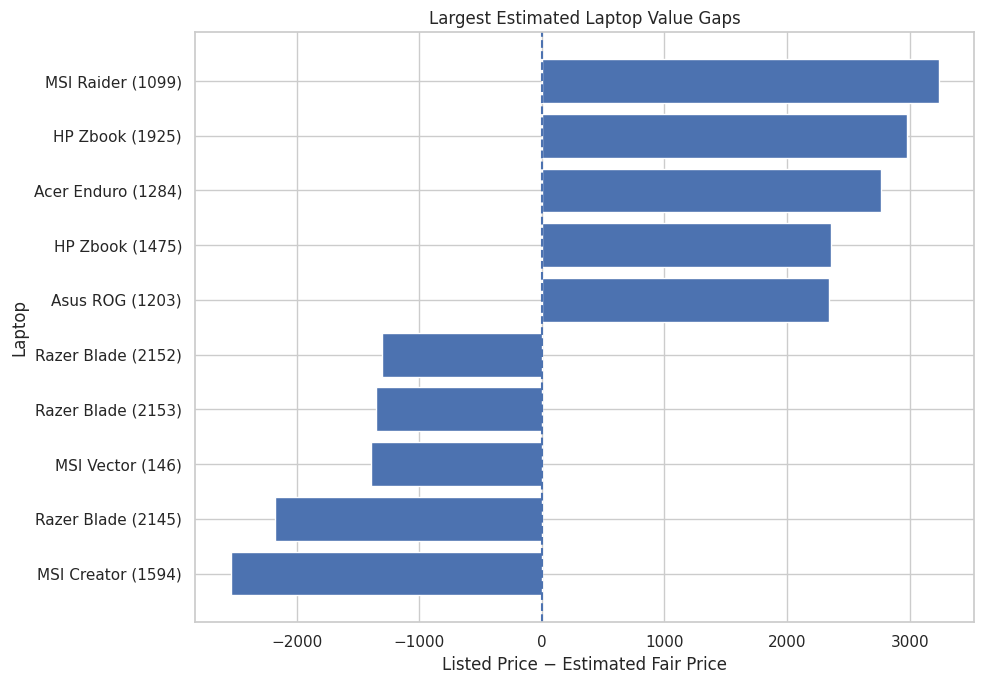

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Select strongest value-gap examples
under = (
    df_value[df_value["value_category"] == "Potentially Underpriced"]
    .nsmallest(5, "price_difference")
)

over = (
    df_value[df_value["value_category"] == "Potentially Overpriced"]
    .nlargest(5, "price_difference")
)

value_gap = pd.concat([under, over])

# Create readable labels
value_gap["label"] = (
    value_gap["brand"] + " " +
    value_gap["model"] + " (" +
    value_gap.index.astype(str) + ")"
)

# Sort for visualization
value_gap = value_gap.sort_values("price_difference")

plt.figure(figsize=(10, 7))

plt.barh(
    value_gap["label"],
    value_gap["price_difference"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Listed Price − Estimated Fair Price")
plt.ylabel("Laptop")
plt.title("Largest Estimated Laptop Value Gaps")

plt.tight_layout()
plt.show()

Project Summary

In [ ]:
print("=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print("\nBest Model: Linear Regression")
print("Test MAE: 260.82")
print("Test RMSE: 390.13")
print("Test R²: 0.835")

print("\n5-Fold Cross-Validation:")
print("CV MAE: 288.69")
print("CV RMSE: 413.66")
print("CV R²: 0.780")

print("\nValue Assessment:")
print("Potentially Underpriced: 902 (41.76%)")
print("Fairly Priced: 587 (27.18%)")
print("Potentially Overpriced: 671 (31.06%)")

print("\nMost influential features:")
print("1. GPU")
print("2. CPU")
print("3. RAM")
print("4. Brand")
print("5. Storage")

print("\nFair-price threshold: ±10%")
print("=" * 60)

PROJECT SUMMARY

Best Model: Linear Regression
Test MAE: 260.82
Test RMSE: 390.13
Test R²: 0.835

5-Fold Cross-Validation:
CV MAE: 288.69
CV RMSE: 413.66
CV R²: 0.780

Value Assessment:
Potentially Underpriced: 902 (41.76%)
Fairly Priced: 587 (27.18%)
Potentially Overpriced: 671 (31.06%)

Most influential features:
1. GPU
2. CPU
3. RAM
4. Brand
5. Storage

Fair-price threshold: ±10%
